# Лабораторная работа №4
Егорова Варвара Александровна, P3323, 408575

## Задание
Решить задачу классификации изображений на наборе данных из лабораторной работы "Классификация изображений" с использованием предобученных моделей нейронных сетей (например, VGG16, ResNet50 и др.).
1. Провести эксперименты с замороженными весами модели и настройкой только классификатора.
2. Провести тонкую настройк сети, разморозив один или несколько слоев предобученной нейронной сети.

Подготовить отчет с описанием проведенных экспериментов и анализом полученных результатов.

## Загружаем и предобрабатываем датасет

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
classes = ['футболка', 'брюки', 'свитер', 'платье', 'пальто', 'туфли', 'рубашка', 'кроссовки', 'сумка', 'ботинки']

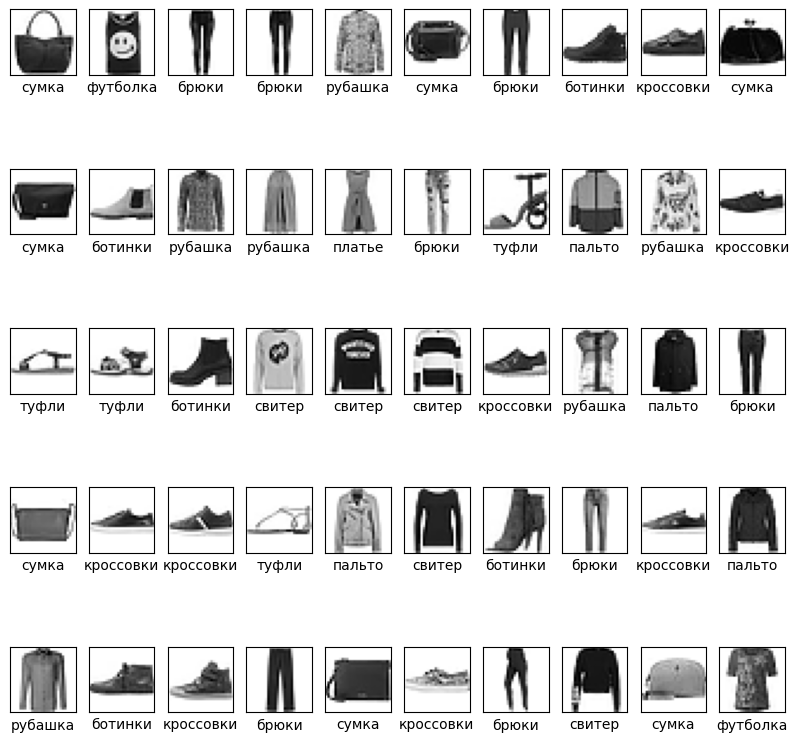

In [ ]:
plt.figure(figsize=(10,10))
for i in range(100,150):
    plt.subplot(5,10,i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(classes[y_train[i]])

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [ ]:
def preprocess_for_pretrained(x, y):
    x = tf.expand_dims(x, axis=-1)        # (28,28,1)
    x = tf.image.grayscale_to_rgb(x)       # (28,28,3)
    x = tf.image.resize(x, (224, 224))     # resize под модель
    return x, y


In [ ]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess_for_pretrained, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess_for_pretrained, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

## Загружаем предобученную модель

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Загружаем базовую модель без классификатора
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Замораживаем все слои предобученной сети
base_model.trainable = False

# Добавляем свой классификатор
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 398s 203ms/step - accuracy: 0.5922 - loss: 1.1676 - val_accuracy: 0.8027 - val_loss: 0.5541
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 374s 199ms/step - accuracy: 0.7891 - loss: 0.5873 - val_accuracy: 0.8281 - val_loss: 0.4788
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 374s 199ms/step - accuracy: 0.8112 - loss: 0.5212 - val_accuracy: 0.8316 - val_loss: 0.4561
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 374s 199ms/step - accuracy: 0.8239 - loss: 0.4864 - val_accuracy: 0.8301 - val_loss: 0.4562
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 374s 199ms/step - accuracy: 0.8319 - loss: 0.4687 - val_accuracy: 0.8405 - val_loss: 0.4305


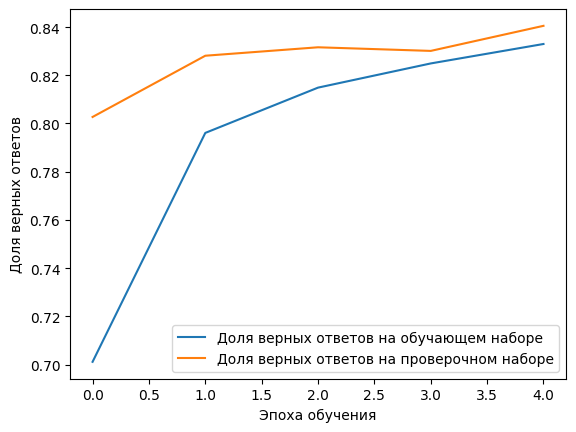

In [ ]:
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.8459 - loss: 0.4193
Test accuracy: 0.840499997138977


## Разморозим несколько слоёв и уменьшим lr

In [ ]:
# Размораживаем последние слои VGG16
for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_finetune = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 433s 227ms/step - accuracy: 0.8559 - loss: 0.4003 - val_accuracy: 0.8811 - val_loss: 0.3156
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 426s 227ms/step - accuracy: 0.8982 - loss: 0.2856 - val_accuracy: 0.8921 - val_loss: 0.2893
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 426s 227ms/step - accuracy: 0.9135 - loss: 0.2403 - val_accuracy: 0.9071 - val_loss: 0.2554
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 426s 227ms/step - accuracy: 0.9272 - loss: 0.2080 - val_accuracy: 0.9138 - val_loss: 0.2448
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 425s 227ms/step - accuracy: 0.9343 - loss: 0.1857 - val_accuracy: 0.9159 - val_loss: 0.2359


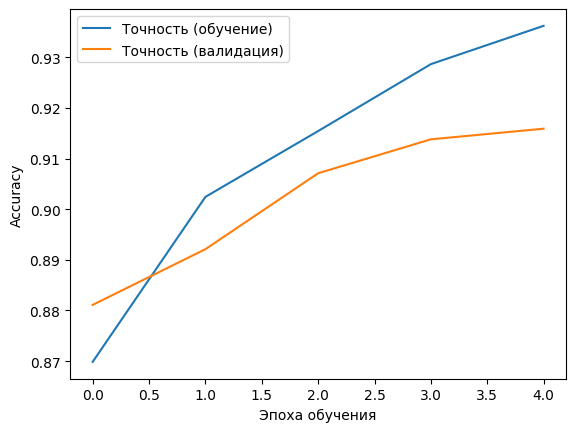

In [ ]:
plt.plot(history_finetune.history['accuracy'],
         label='Точность (обучение)')
plt.plot(history_finetune.history['val_accuracy'],
         label='Точность (валидация)')

plt.xlabel('Эпоха обучения')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy after fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.9181 - loss: 0.2248
Test accuracy after fine-tuning: 0.9158999919891357


## Попробуем разморозить целый блок

In [ ]:
for layer in base_model.layers:
    layer.trainable = False
    if "block5" in layer.name:
        layer.trainable = True


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_block5 = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 431s 227ms/step - accuracy: 0.9399 - loss: 0.1659 - val_accuracy: 0.9186 - val_loss: 0.2338
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 426s 227ms/step - accuracy: 0.9466 - loss: 0.1486 - val_accuracy: 0.9210 - val_loss: 0.2283
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 426s 227ms/step - accuracy: 0.9542 - loss: 0.1316 - val_accuracy: 0.9185 - val_loss: 0.2347
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 425s 227ms/step - accuracy: 0.9587 - loss: 0.1192 - val_accuracy: 0.9208 - val_loss: 0.2471
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 425s 227ms/step - accuracy: 0.9608 - loss: 0.1077 - val_accuracy: 0.9245 - val_loss: 0.2342


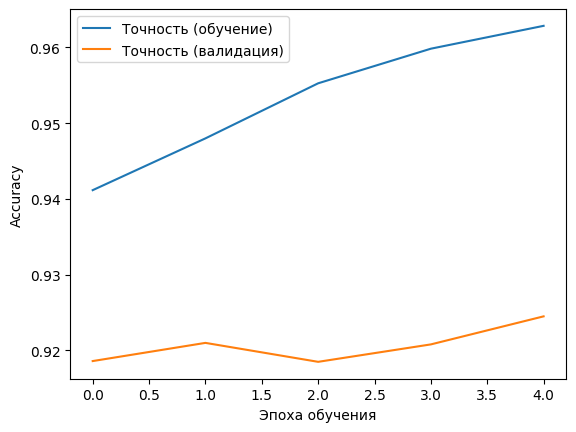

In [ ]:
plt.plot(history_block5.history['accuracy'],
         label='Точность (обучение)')
plt.plot(history_block5.history['val_accuracy'],
         label='Точность (валидация)')

plt.xlabel('Эпоха обучения')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.9272 - loss: 0.2243
Test accuracy: 0.9244999885559082


## Пробуем разморозить 2 блока

In [ ]:
for layer in base_model.layers:
    layer.trainable = False
    if "block4" in layer.name or "block5" in layer.name:
        layer.trainable = True


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_block45 = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 566s 295ms/step - accuracy: 0.9546 - loss: 0.1230 - val_accuracy: 0.9185 - val_loss: 0.2475
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 551s 294ms/step - accuracy: 0.9630 - loss: 0.1039 - val_accuracy: 0.9150 - val_loss: 0.2729
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 552s 294ms/step - accuracy: 0.9654 - loss: 0.0956 - val_accuracy: 0.9263 - val_loss: 0.2387
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 552s 294ms/step - accuracy: 0.9717 - loss: 0.0802 - val_accuracy: 0.9236 - val_loss: 0.2573
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 552s 294ms/step - accuracy: 0.9763 - loss: 0.0686 - val_accuracy: 0.9230 - val_loss: 0.2717


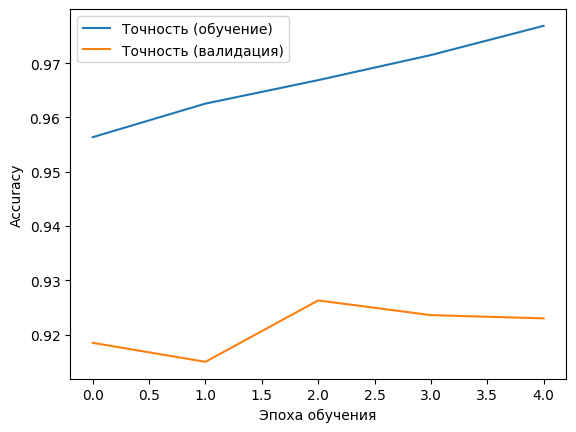

In [ ]:
plt.plot(history_block45.history['accuracy'],
         label='Точность (обучение)')
plt.plot(history_block45.history['val_accuracy'],
         label='Точность (валидация)')

plt.xlabel('Эпоха обучения')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.9251 - loss: 0.2627
Test accuracy: 0.9229999780654907
